## Importing Libraries



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from os import path

## Machine learning models importing

from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report
from sklearn import metrics

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from  sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

## Loading the dataset

In [ ]:
bot_path = "/content/bot-iot.csv"
ton_path = "/content/ton-iot.csv"

bot_data = pd.read_csv(bot_path)
ton_data = pd.read_csv(ton_path)

print("BOT-IOT Shape: ", bot_data.shape)
print("TON-IOT Shape: ",ton_data.shape)

BOT-IOT Shape:  (58829, 46)
TON-IOT Shape:  (19, 45)


## Data Preprocessing

In [ ]:
bot_data.head()

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1,1.528089e+09,e,1,tcp,1,192.168.100.147,49960,192.168.100.7,80,...,1.12704,96.0,75.0,1.133720,1.129970,770.0,602.0,1.0,DoS,HTTP
1,2,1.528089e+09,e,1,arp,2,192.168.100.7,-1,192.168.100.147,-1,...,15267.20000,1.0,2.0,0.005142,0.005142,2.0,6.0,1.0,DoS,HTTP
2,3,1.528089e+09,e,1,tcp,1,192.168.100.147,49962,192.168.100.7,80,...,1.12704,96.0,75.0,1.135100,1.129970,770.0,602.0,1.0,DoS,HTTP
3,4,1.528089e+09,e,1,tcp,1,192.168.100.147,49964,192.168.100.7,80,...,1.12704,96.0,75.0,1.135140,1.129970,770.0,602.0,1.0,DoS,HTTP
4,5,1.528089e+09,e,1,tcp,1,192.168.100.147,49966,192.168.100.7,80,...,1.12704,96.0,75.0,1.135260,1.129970,770.0,602.0,1.0,DoS,HTTP


In [ ]:
ton_data.head()

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0,0,-,-,-,bad_UDP_checksum,-,F,0,normal


In [ ]:
print("The Information of BOt_IOT: ",bot_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58829 entries, 0 to 58828
Data columns (total 46 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   pkSeqID                           58829 non-null  int64  
 1   stime                             58829 non-null  float64
 2   flgs                              58829 non-null  object 
 3   flgs_number                       58829 non-null  int64  
 4   proto                             58829 non-null  object 
 5   proto_number                      58829 non-null  int64  
 6   saddr                             58829 non-null  object 
 7   sport                             58829 non-null  int64  
 8   daddr                             58829 non-null  object 
 9   dport                             58829 non-null  int64  
 10  pkts                              58829 non-null  int64  
 11  bytes                             58828 non-null  float64
 12  stat

In [ ]:
print("The Information of TON_IOT: ",ton_data.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ts                      19 non-null     int64  
 1   src_ip                  19 non-null     object 
 2   src_port                19 non-null     int64  
 3   dst_ip                  19 non-null     object 
 4   dst_port                19 non-null     int64  
 5   proto                   19 non-null     object 
 6   service                 19 non-null     object 
 7   duration                19 non-null     float64
 8   src_bytes               19 non-null     int64  
 9   dst_bytes               19 non-null     int64  
 10  conn_state              19 non-null     object 
 11  missed_bytes            19 non-null     int64  
 12  src_pkts                19 non-null     int64  
 13  src_ip_bytes            19 non-null     int64  
 14  dst_pkts                19 non-null     int6

In [ ]:
ton_data[ton_data['service']== '-']

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
5,1554198364,192.168.1.79,33269,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
6,1554198364,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
7,1554198364,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
8,1556203822,192.168.1.31,60556,192.168.1.152,80,tcp,-,0.000002,0,0,...,0,0,-,-,-,-,-,-,1,dos
9,1556203822,192.168.1.31,60582,192.168.1.152,80,tcp,-,31.639032,0,0,...,0,0,-,-,-,-,-,-,1,dos
10,1556203822,192.168.1.31,60584,192.168.1.152,80,tcp,-,31.634963,0,0,...,0,0,-,-,-,-,-,-,1,ddos


In [ ]:
ton_data[['service','dns_query','dns_AA','dns_RA','dns_rejected','dns_rejected','ssl_cipher','ssl_resumed','ssl_established','ssl_subject','ssl_issuer','http_trans_depth','http_method','http_uri','http_version','http_user_agent','http_orig_mime_types','http_resp_mime_types','weird_name','weird_addl','weird_notice']].replace('-','nil',inplace=True)

/tmp/ipython-input-3871750268.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ton_data[['service','dns_query','dns_AA','dns_RA','dns_rejected','dns_rejected','ssl_cipher','ssl_resumed','ssl_established','ssl_subject','ssl_issuer','http_trans_depth','http_method','http_uri','http_version','http_user_agent','http_orig_mime_types','http_resp_mime_types','weird_name','weird_addl','weird_notice']].replace('-','nil',inplace=True)


In [ ]:
ton_data.isnull().sum()

,0
ts,0
src_ip,0
src_port,0
dst_ip,0
dst_port,0
proto,0
service,0
duration,0
src_bytes,0
dst_bytes,0


In [ ]:
bot_data.isnull().sum()


,0
pkSeqID,0
stime,0
flgs,0
flgs_number,0
proto,0
proto_number,0
saddr,0
sport,0
daddr,0
dport,0


In [ ]:
ton_data.duplicated().sum()


np.int64(0)

In [ ]:
bot_data.duplicated().sum()


np.int64(0)

In [ ]:
print("BOT-IOT Shape: ", bot_data.shape)
print("TON-IOT Shape: ",ton_data.shape)

BOT-IOT Shape:  (58829, 46)
TON-IOT Shape:  (19, 45)


In [ ]:
# Remove duplicates
bot_data = bot_data.drop_duplicates()
ton_data = ton_data.drop_duplicates()

In [ ]:
print("After removing duplicates:")
print("BOT shape:", bot_data.shape)
print("TON shape:", ton_data.shape)

After removing duplicates:
BOT shape: (58829, 46)
TON shape: (19, 45)


In [ ]:
print("BOT-IOT data: " , bot_data.dropna(inplace = True))
print("TON-IOT Data: ", ton_data.dropna(inplace=True))

BOT-IOT data:  None
TON-IOT Data:  None


In [ ]:
bot_data[['attack','category','subcategory']].value_counts()

attack  category  subcategory
1.0     DoS       TCP            57343
                  HTTP            1485
Name: count, dtype: int64

In [ ]:
ton_data[['label','type']].value_counts()

,,count
label,type,
1,ddos,9
0,normal,8
1,dos,2


In [ ]:
bot_target = ['attack','category','subcategory']
print(bot_target)
ton_target = 'label'
print(ton_target)

['attack', 'category', 'subcategory']
label


In [ ]:
print("BOT Target Values:\n", bot_data[bot_target].value_counts())
print("TON Target Values:\n", ton_data[ton_target].value_counts())

BOT Target Values:
 attack  category  subcategory
1.0     DoS       TCP            57343
                  HTTP            1485
Name: count, dtype: int64
TON Target Values:
 label
1    11
0     8
Name: count, dtype: int64


In [ ]:
ton_data

,ts,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,1554198358,3.122.49.24,1883,192.168.1.152,52976,tcp,-,80549.530260,1762852,41933215,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
1,1554198358,192.168.1.79,47260,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
2,1554198359,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,bad_TCP_checksum,-,F,0,normal
3,1554198359,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
4,1554198362,192.168.1.152,46608,192.168.1.190,53,udp,dns,0.000549,0,298,...,0,0,-,-,-,bad_UDP_checksum,-,F,0,normal
5,1554198364,192.168.1.79,33269,192.168.1.255,15600,udp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
6,1554198364,192.168.1.152,34296,192.168.1.152,10502,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
7,1554198364,192.168.1.152,1880,192.168.1.152,51782,tcp,-,0.000000,0,0,...,0,0,-,-,-,-,-,-,0,normal
8,1556203822,192.168.1.31,60556,192.168.1.152,80,tcp,-,0.000002,0,0,...,0,0,-,-,-,-,-,-,1,dos
9,1556203822,192.168.1.31,60582,192.168.1.152,80,tcp,-,31.639032,0,0,...,0,0,-,-,-,-,-,-,1,dos


In [ ]:
bot_data

,pkSeqID,stime,flgs,flgs_number,proto,proto_number,saddr,sport,daddr,dport,...,AR_P_Proto_P_DstIP,N_IN_Conn_P_DstIP,N_IN_Conn_P_SrcIP,AR_P_Proto_P_Sport,AR_P_Proto_P_Dport,Pkts_P_State_P_Protocol_P_DestIP,Pkts_P_State_P_Protocol_P_SrcIP,attack,category,subcategory
0,1,1.528089e+09,e,1,tcp,1,192.168.100.147,49960,192.168.100.7,80,...,1.127040,96.0,75.0,1.133720,1.129970,770.0,602.0,1.0,DoS,HTTP
1,2,1.528089e+09,e,1,arp,2,192.168.100.7,-1,192.168.100.147,-1,...,15267.200000,1.0,2.0,0.005142,0.005142,2.0,6.0,1.0,DoS,HTTP
2,3,1.528089e+09,e,1,tcp,1,192.168.100.147,49962,192.168.100.7,80,...,1.127040,96.0,75.0,1.135100,1.129970,770.0,602.0,1.0,DoS,HTTP
3,4,1.528089e+09,e,1,tcp,1,192.168.100.147,49964,192.168.100.7,80,...,1.127040,96.0,75.0,1.135140,1.129970,770.0,602.0,1.0,DoS,HTTP
4,5,1.528089e+09,e,1,tcp,1,192.168.100.147,49966,192.168.100.7,80,...,1.127040,96.0,75.0,1.135260,1.129970,770.0,602.0,1.0,DoS,HTTP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58823,58824,1.528081e+09,e g,5,tcp,1,192.168.100.150,6565,192.168.100.3,80,...,0.252934,52.0,52.0,0.252543,0.198757,312.0,312.0,1.0,DoS,TCP
58824,58825,1.528081e+09,e g,5,tcp,1,192.168.100.150,6514,192.168.100.3,80,...,0.252934,52.0,52.0,0.252976,0.198757,312.0,312.0,1.0,DoS,TCP
58825,58826,1.528081e+09,e g,5,tcp,1,192.168.100.150,6515,192.168.100.3,80,...,0.252934,52.0,52.0,0.252976,0.198757,312.0,312.0,1.0,DoS,TCP
58826,58827,1.528081e+09,e g,5,tcp,1,192.168.100.150,6518,192.168.100.3,80,...,0.252934,52.0,52.0,0.252976,0.198757,312.0,312.0,1.0,DoS,TCP


## ENCODING


In [ ]:
def encode_dataframe(df):
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object']).columns:
        # Convert all values in the column to string type before encoding
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
    return df

bot_data = encode_dataframe(bot_data)
ton_data = encode_dataframe(ton_data)

In [ ]:
# BOT
X_bot = bot_data.drop(columns=bot_target)
y_bot = bot_data[bot_target]

# TON
X_ton = ton_data.drop(columns=[ton_target])
y_ton = ton_data[ton_target]

In [ ]:
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bot, y_bot, test_size=0.2, random_state=42
)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_ton, y_ton, test_size=0.2, random_state=42, stratify=y_ton
)

print("BOT Train Shape:", Xb_train.shape)
print("TON Train Shape:", Xt_train.shape)

BOT Train Shape: (47062, 43)
TON Train Shape: (15, 44)


In [ ]:
scaler = MinMaxScaler()

In [ ]:
scaler.fit(Xb_train)
Xb_train = scaler.transform(Xb_train)
Xb_test = scaler.transform(Xb_test)


## TRAIN MULTIPLE MODEL

In [ ]:
from sklearn.multioutput import MultiOutputClassifier

lr_bot = MultiOutputClassifier(LogisticRegression(max_iter=1000, solver='liblinear'))

# Identify columns in yb_train that have more than one unique class
viable_target_cols_bot = [col for col in yb_train.columns if yb_train[col].nunique() > 1]

if not viable_target_cols_bot:
    print("No viable target columns for Logistic Regression found in yb_train (all columns have only one class).")
else:
    yb_train_filtered = yb_train[viable_target_cols_bot]
    yb_test_filtered = yb_test[viable_target_cols_bot]

    lr_bot.fit(Xb_train, yb_train_filtered)

    bot_pred_rf = lr_bot.predict(Xb_test)

    print("BOT Logistic Regression Accuracies per output:")
    for i, target_col in enumerate(yb_test_filtered.columns):
        print(f"  {target_col}: {accuracy_score(yb_test_filtered.iloc[:, i], bot_pred_rf[:, i]):.4f}")

BOT Logistic Regression Accuracies per output:
  subcategory: 1.0000


In [ ]:
rf_ton = RandomForestClassifier(n_estimators=100)
rf_ton.fit(Xt_train, yt_train)

ton_pred_rf = rf_ton.predict(Xt_test)

print("TON RF Accuracy:", accuracy_score(yt_test, ton_pred_rf))
print(classification_report(yt_test, ton_pred_rf))

TON RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



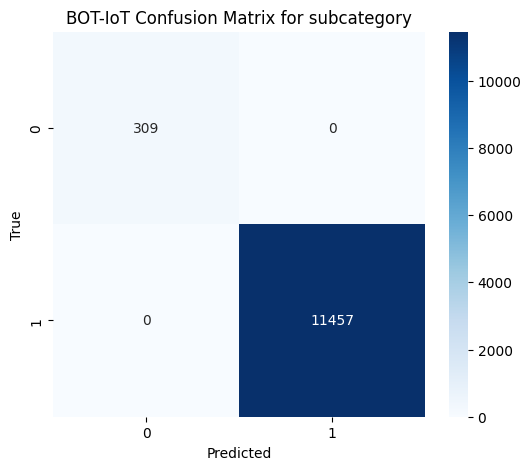

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for i, target_col in enumerate(yb_test_filtered.columns):
    cm = confusion_matrix(yb_test_filtered.iloc[:, i], bot_pred_rf[:, i])

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"BOT-IoT Confusion Matrix for {target_col}")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

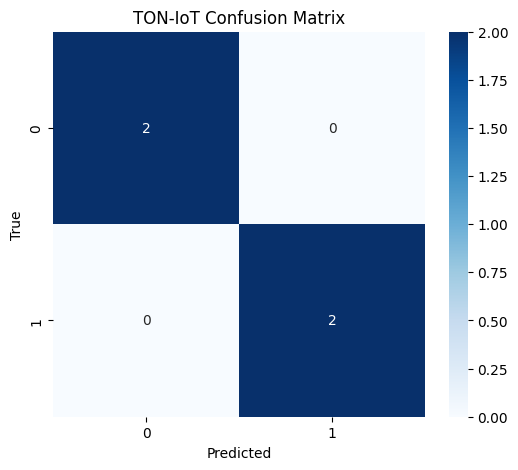

In [ ]:
cm = confusion_matrix(yt_test, ton_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"TON-IoT Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

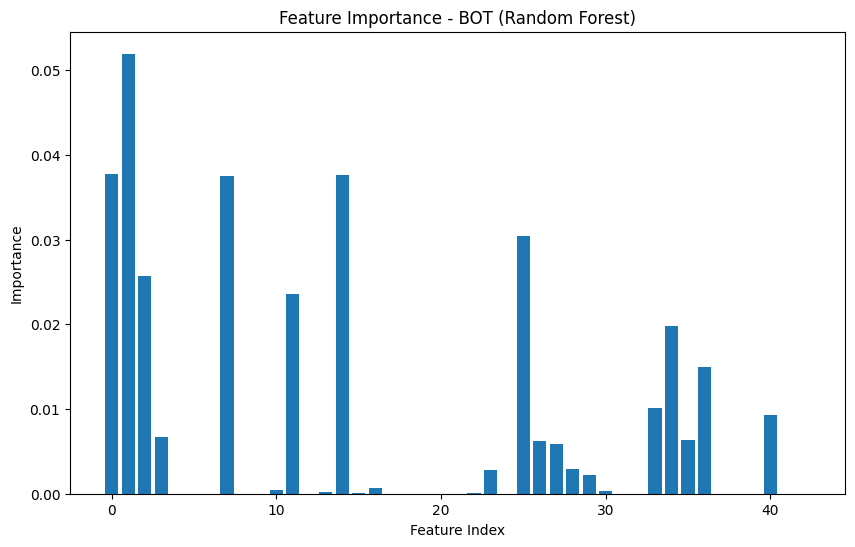

In [ ]:

# Define and train the MultiOutputClassifier with RandomForestClassifier for BOT data
rf_bot = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
rf_bot.fit(Xb_train, yb_train)

# Get feature importances by averaging across all estimators in the MultiOutputClassifier
importances = np.mean([estimator.feature_importances_ for estimator in rf_bot.estimators_], axis=0)

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance - BOT (Random Forest)")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()